# EPEX PORTFOLIO DESIGN

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
from scipy.linalg import cho_factor, cho_solve, LinAlgError
from scipy.fft import fft, fftfreq
from scipy.stats import shapiro, skew, kurtosis, ttest_rel, normaltest,jarque_bera
import scipy.stats as st

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

import json
import math

import requests 
from scipy.optimize import minimize, Bounds, LinearConstraint
from typing import Union, Sequence, Tuple

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### EPEX
The EPEX SPOT portfolio is constructed using day-ahead prices from the Central Western Europe (CWE) bidding zones and Poland, including Austria, Belgium, France, Germany/Luxembourg, the Netherlands, Switzerland, and Poland. These zones represent fully coupled and actively traded areas within the EPEX SPOT market framework. Although the United Kingdom operates a day-ahead electricity market administered by EPEX SPOT, it is not part of the Single Day-Ahead Coupling (SDAC) mechanism following Brexit. Consequently, UK prices are cleared independently from Continental European markets and are not jointly optimized with CWE and Nordic bidding zones. For this reason, UK prices are treated separately and are not directly comparable within the integrated European market coupling framework used in this study.

In [2]:
dfep1 = pd.read_excel(r"C:\Users\gulis\Desktop\Portfolio Design for Electricty Market\Avrupa Market\Data\nordpool_and_epex.xlsx",sheet_name="EPEX")
dfep = dfep1.drop(columns=["Delivery Date (CET)"])

Veri test ve eğitim kümesi olarak ikiye bölündü. Train ile elde edilen oranlar test verisinde kullanılacak.

In [3]:
border = 180
test_df = dfep.tail(border)   # Test set (son 180 satır)
train_df = dfep.iloc[:-border]   # Train set (geri kalan)

## PLOTS AND DESCRİBE

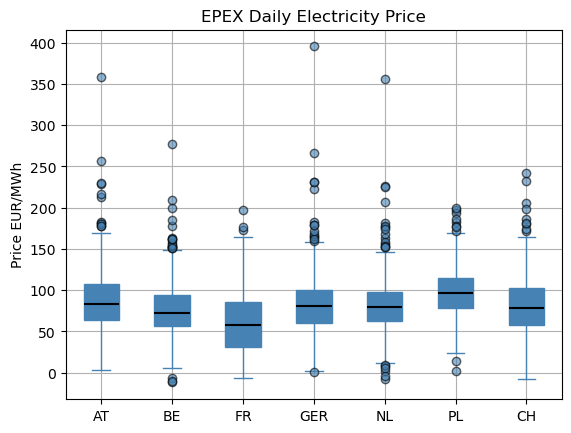

In [4]:
ax = train_df.boxplot(
         patch_artist=True,        # box'ların içini boyamak için şart
         boxprops=dict(facecolor="steelblue", color="steelblue"),
         medianprops=dict(color="black", linewidth=1.5),
         whiskerprops=dict(color="steelblue"),
         capprops=dict(color="steelblue"),
         flierprops=dict(marker='o', markerfacecolor='steelblue', alpha=0.6))
ax.set_ylabel("Price EUR/MWh")
ax.set_title("EPEX Daily Electricity Price")
plt.show()

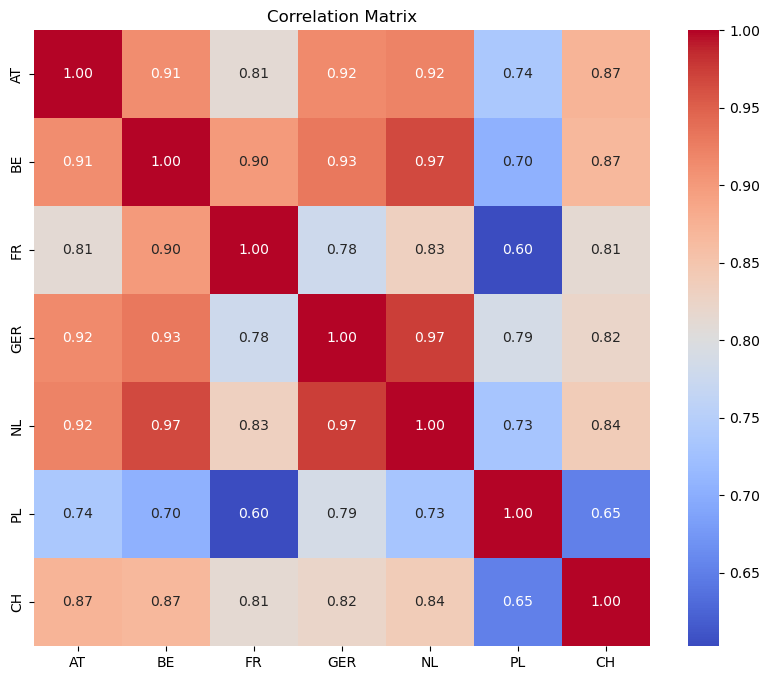

In [5]:
corr = train_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()

In [6]:
train_df.describe().T.style.format("{:.0f}")

,count,mean,std,min,25%,50%,75%,max
AT,551,87,37,3,64,83,108,359
BE,551,77,34,-12,56,73,94,277
FR,551,61,38,-6,31,57,85,197
GER,551,83,37,1,60,81,100,395
NL,551,82,34,-8,63,79,97,356
PL,551,98,29,2,78,96,115,200
CH,551,82,36,-8,57,79,102,242


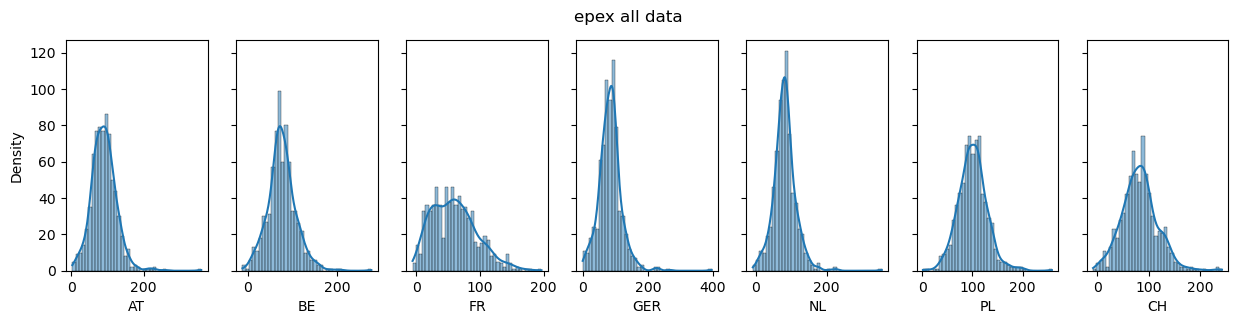

In [7]:
fig, axes = plt.subplots(1, 7, figsize=(15, 3), sharey=True)
sns.histplot(dfep["AT"], bins=40, kde=True, ax=axes[0])
sns.histplot(dfep["BE"], bins=40, kde=True, ax=axes[1])
sns.histplot(dfep["FR"], bins=40, kde=True, ax=axes[2])
sns.histplot(dfep["GER"],bins=40, kde=True, ax=axes[3])
sns.histplot(dfep["NL"], bins=40, kde=True, ax=axes[4])
sns.histplot(dfep["PL"],bins=40, kde=True, ax=axes[5])
sns.histplot(dfep["CH"],bins=40, kde=True, ax=axes[6])
axes[0].set_ylabel("Density")
fig.suptitle("epex all data", fontsize=12)
plt.show()

In [8]:
def stat(series):
    name = series.name             
    data = series.dropna().values   

    stat, p = shapiro(data)
    stat, pk2 = normaltest(data)
    stat, pjb = jarque_bera(data)

    print("values:", name)
    print("shapiro  p-value:", f"{p:.3f}")
    print("kare    p-value:", f"{pk2:.3f}")
    print("jarque  p-value:", f"{pjb:.3f}")

    print("Skewness value :", f"{skew(data):.3f}")
    print("Kurtosis value :", f"{kurtosis(data):.3f}")

    # --- Q-Q Plot ---
    st.probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot — {name}")   
    plt.show() 

values: AT
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 1.083
Kurtosis value : 5.781


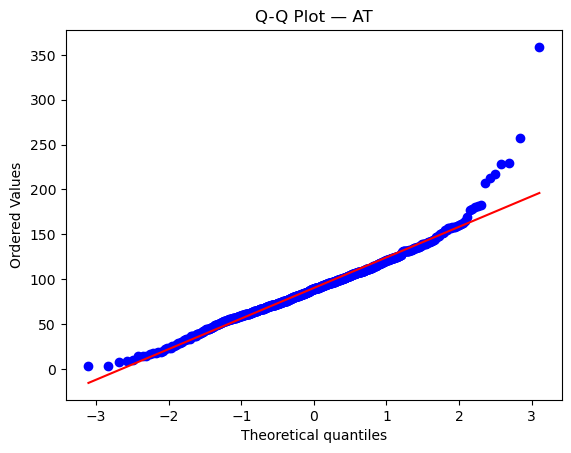

values: BE
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 0.641
Kurtosis value : 2.727


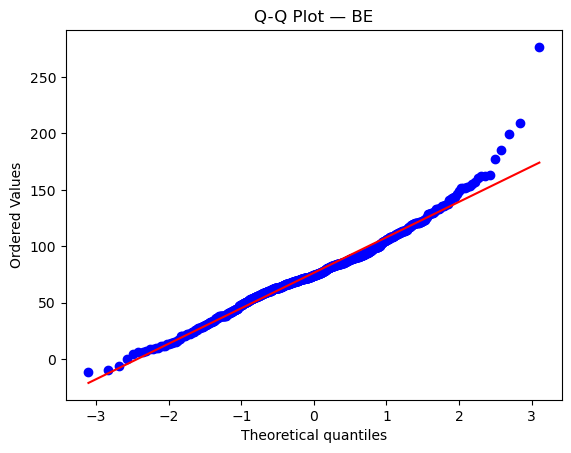

values: FR
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 0.592
Kurtosis value : 0.101


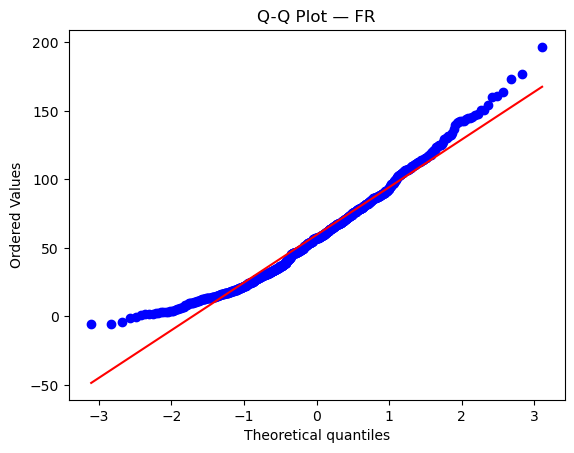

values: GER
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 1.460
Kurtosis value : 9.918


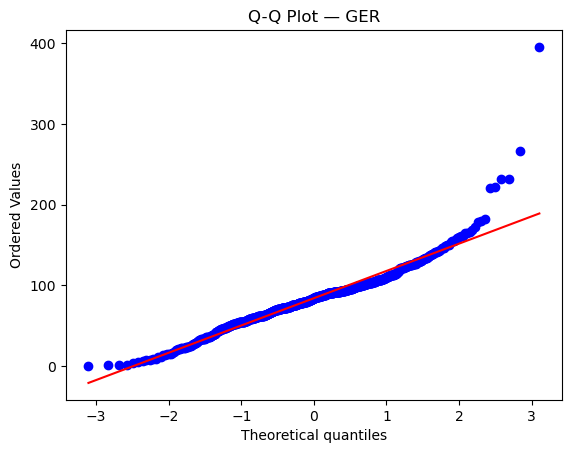

values: NL
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 1.203
Kurtosis value : 8.385


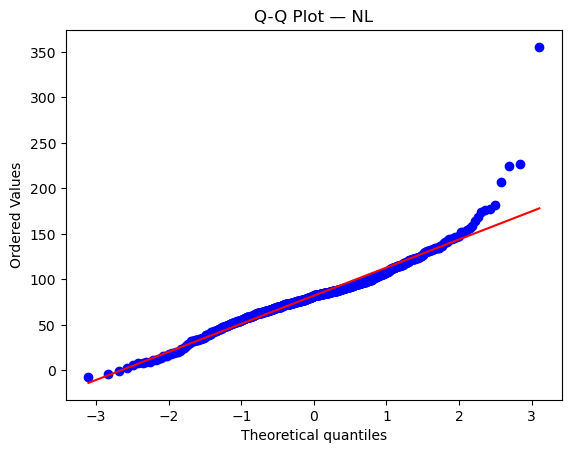

values: PL
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 0.421
Kurtosis value : 1.787


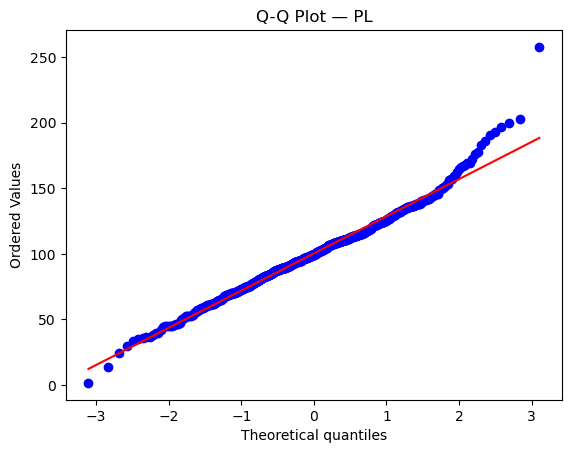

values: CH
shapiro  p-value: 0.000
kare    p-value: 0.000
jarque  p-value: 0.000
Skewness value : 0.516
Kurtosis value : 1.369


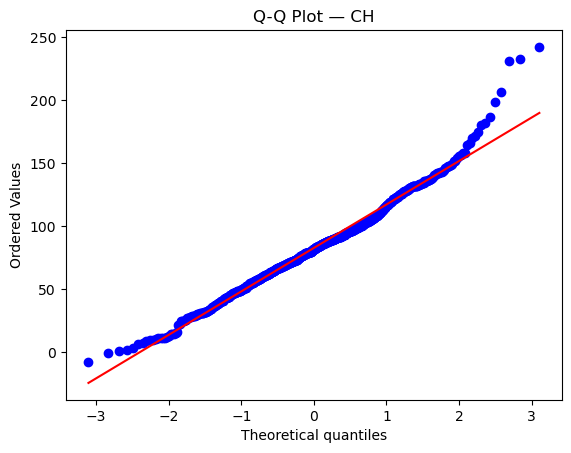

In [9]:
for col in train_df.columns:
    stat(dfep[col])

##  PORTFOLIO DESIGN

In [10]:
def optimalPortfoliononshort(
    df: pd.DataFrame,
    C: float,
    gamma: float,
    lower_bounds: Union[float, Sequence[float]] = 0.0,
    upper_bounds: Union[float, Sequence[float]] = 1.0,
    ridge: float = 1e-8,
) -> Tuple[pd.Series, float, float]:
    """
    Solve:  min_λ  C μ^T λ + γ C^2 λ^T Σ λ
            s.t.   1^T λ = 1,  lb ≤ λ ≤ ub
    df: price levels (rows=time, cols=sources). Returns (λ*, E[X], Var[X]).
    """
    if C <= 0 or gamma <= 0:
        raise ValueError("C and gamma must be > 0.")                              # risk katsayısı ve C >0 olmalı
    X = df.dropna(axis=1, how="all").dropna(axis=0, how="any").astype(float)      # Nan lar atılır
    if X.shape[0] < 2 or X.shape[1] < 1:
        raise ValueError("Not enough data.")                                      # Cov için boyutu minumum 2x2 olmalıdır

    mu = X.mean().to_numpy()                                                      # E[p]
    Sigma = X.cov(ddof=1).to_numpy()                                              # Cov[p], ddof=1 by default
    Sigma = 0.5 * (Sigma + Sigma.T) + ridge * np.eye(len(mu))                     # Symmetrize to dampen numerical asymmetry
    n = len(mu)                                                                   # mu boyutu bulundu

    # expand bounds to vectors
    lb = np.full(n, lower_bounds if np.isscalar(lower_bounds) else np.asarray(lower_bounds, float))  #lower bound
    ub = np.full(n, upper_bounds if np.isscalar(upper_bounds) else np.asarray(upper_bounds, float))  #Upper bound
    #if lb.sum() > 1 + 1e-12 or ub.sum() < 1 - 1e-12:
    #    raise ValueError("Infeasible bounds: need sum(lb) ≤ 1 ≤ sum(ub).")                           #sum(lb) ≤ 1 ≤ sum(ub) şartını manuel test ediyor

    # feasible start: begin at lb, spread remaining mass toward ub
    w0 = lb.copy()                                         # ilk olarak ağırlıklar minimuma eşitleniyor
    rem = 1.0 - w0.sum()                                   # Eşitlik koşulundan yola çıkarak 1'den çıkarılıyor
    if rem > 0:                                            # Ağırlıklar bulunur
        room = np.maximum(ub - w0, 0.0)
        total = room.sum()
        if total > 0: w0 += rem * (room / total)           # toplamın 1 e eşit olduğu sağlanır
    w0 = np.clip(w0, lb, ub)                               # ağırlıkları (w) sınırlar içinde burakır

    def fun(w):  return C * mu @ w + gamma * (C**2) * (w @ Sigma @ w)  #fonksiyon f(w)=Cμ⊤w+γC2w⊤Σw amaç fonk  scaler
    def jac(w):  return C * mu + 2.0 * gamma * (C**2) * (Sigma @ w)    #jacobien  ∇f(w)=Cμ+2γC2Σw   1. Türev   (n,)
    def hess(w): return 2.0 * gamma * (C**2) * Sigma                   #hessian   ∇2f(w)=2γC2Σ      2. Türev   (n,n)

    cons = [LinearConstraint(np.ones((1, n)), 1.0, 1.0)]                # w vektörü ve sınırlar toplamlar 1 e eşit
    bnds = Bounds(lb, ub)                                               # Sınırlar 
    opt  = minimize(fun, w0, method="trust-constr", jac=jac, hess=hess, # Optimizasyon tam olarak burda yapılır ve newton tabanlıdır.
                   bounds=bnds, constraints=cons,
                   options={"maxiter": 500, "gtol": 1e-10, "xtol": 1e-12, "verbose": 0})  
    #gtol=1e-10	Gradyan normu bu değerden küçükse dur.
    #xtol=1e-12	w vektöründeki değişim bu değerden küçükse dur.
    #maxiter=500	Maksimum iterasyon sayısı.
    #verbose=0	Çıktı susturulmuş. 2 yapsan her adımı loglar.
    
    
    if not opt.success:
        raise RuntimeError(f"Optimization failed: {opt.message}")  # algoritmanın neden durduğunu açıklayan yazı "opt.***" gibi türev bilgi verilebilir.

    w = pd.Series(opt.x, index=X.columns, name="No-Short")
    E = C * float(mu @ opt.x)
    V = (C**2) * float(opt.x.T @ Sigma @ opt.x)
    return w, E, V

In [11]:
def presults(data , datatest= test_df):
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning, module="scipy")

    #######################  W AĞIRLIKLARIN BELİRLENMESİ ################################################################################
    #####################################################################################################################################
    prices = data.dropna()
    prices.reset_index(drop=True, inplace=True)

    C=10000
    gamma= 1  #risk katsayısı
    n = prices.shape[1]                                    # cov boyutu bulundu
    upper_bounds  = np.full(n,  0.3)  
    lower_bounds  = np.full(n, -0.3) 
    upper_bounds2 = np.full(n, 3)  
    lower_bounds2 = np.full(n, -3)         
  
    w1, E1, V1 = optimalPortfoliononshort(prices, C=C, gamma=gamma )
    w2, E2, V2 = optimalPortfoliononshort(prices, C=C, gamma=gamma,  upper_bounds=upper_bounds  , lower_bounds=lower_bounds)
    w3, E3, V3 = optimalPortfoliononshort(prices, C=C, gamma=gamma,  upper_bounds=upper_bounds2 , lower_bounds=lower_bounds2)
    
    w1_df = w1.copy()
    w2_df = w2.copy()
    w3_df = w3.copy()
    
    weights_df = pd.concat([w1_df, w2_df, w3_df], axis=1)
    weights_df.columns = ["P1 non-short","P2 with limited UB-LB","P3 with short"]
    weights_df = weights_df.round(2)
    print(weights_df)

    #######################  TEST KÜMESİ  ###############################################################################################
    #####################################################################################################################################

    datatest = datatest.dropna().copy()
    datatest1 = datatest[w1.index]
    datatest2 = datatest[w2.index]
    datatest3 = datatest[w3.index]
    
    E_test1 = C * (datatest @ w1)
    E_test2 = C * (datatest @ w2)
    E_test3 = C * (datatest @ w3)
    V_test1 = E_test1.std()
    V_test2 = E_test2.std()
    V_test3 = E_test3.std()
   
    E_tests = pd.DataFrame({"P1": [E_test1.mean()],"P2": [E_test2.mean()],"P3": [E_test3.mean()]})
    V_tests = pd.DataFrame({"P1": [V_test1],"P2": [V_test2],"P3": [V_test3]})
    test = pd.concat([E_tests, V_tests], axis=0)
    print("test results")
    display(test.T.style.format("{:,.0f}"))
    
    
    '''    
    plt.figure(figsize=(10,8))
    sns.heatmap(weights_df, annot=True, fmt=".2f", cmap="coolwarm" , square=True)
    plt.title("Weight Matrix")
    plt.show()
    '''
    
    #######################  MONTE CARLO  ###############################################################################################
    #####################################################################################################################################

    prices = data.copy()
    prices = prices.dropna().reset_index(drop=True)

    mu = prices.mean().to_numpy()
    Sigma = prices.cov(ddof=1).to_numpy()
    Sigma = 0.5 * (Sigma + Sigma.T)
    
    # weights sırası prices kolonlarıyla aynı olmalı
    lam1 = weights_df.loc[prices.columns, "P1 non-short"].to_numpy()
    lam2 = weights_df.loc[prices.columns, "P2 with limited UB-LB"].to_numpy()
    lam3 = weights_df.loc[prices.columns, "P3 with short"].to_numpy()
    
    n_sim = int(len(data)*2)
    rng = np.random.default_rng(42)
    
    # ============================================================
    # EMPIRICAL MONTE CARLO:
    # Fiyat vektörleri normal dağılımdan üretilmiyor,
    # train kümesindeki gerçek gözlemlerden bootstrap ile seçiliyor
    # ============================================================
    idx = rng.choice(len(prices), size=n_sim, replace=True)
    p = prices.iloc[idx].to_numpy()
    
    # Toplam maliyet
    X1 = C * (p @ lam1)   # P1 non-short
    X2 = C * (p @ lam2)   # P2 with limited UB-LB
    X3 = C * (p @ lam3)   # P3 with short
    
    # İstatistikler
    P1E, P1R = float(X1.mean()), float(X1.std(ddof=0))
    P2E, P2R = float(X2.mean()), float(X2.std(ddof=0))
    P3E, P3R = float(X3.mean()), float(X3.std(ddof=0))
  
    #plot
    p_df = pd.DataFrame(p, columns=prices.columns)
    
    p_df.hist(figsize=(14,10), bins=40)
    plt.suptitle("Distribution of Sampled Prices MC (Per Market)")
    plt.show()
    
    #Dist Information
    results = []
    for col in p_df.columns:
        data = p_df[col].dropna()
    
        # dağılımlar
        dists = {
            "normal": st.norm,
            "lognormal": st.lognorm,
            "gamma": st.gamma,
            "t": st.t
        }
    
        for name, dist in dists.items():
            try:
                params = dist.fit(data)
                ks_stat, p_value = st.kstest(data, name, args=params)
    
                results.append({
                    "Market": col,
                    "Distribution": name,
                    "KS Stat": ks_stat,
                    "p-value": p_value
                })
    
            except:
                pass
    
    df_fit = pd.DataFrame(results)
    df_fit = df_fit.sort_values(["Market", "KS Stat"])
    print(df_fit)

    #######################   E V CALCULATION ###########################################################################################
    #####################################################################################################################################
    
    perf_mc_df = pd.DataFrame({
        "Expected Cost (MC)": [P1E, P2E, P3E],
        "Expected Cost":      [E1, E2, E3], 
        "Risk (Std, MC)":     [P1R, P2R, P3R],
        "Risk (Std)": [np.sqrt(V1), np.sqrt(V2),np.sqrt(V3)]}, 
        index=["P1 Non-Short", "P2 UB-LB", "P3 With Short"])
    display(perf_mc_df.style.format("{:,.0f}"))
    
    return {
    "prices": prices,
    "weights_df": weights_df,
    "perf_mc_df": perf_mc_df,
    "dist": df_fit,
    "w1": w1, "w2": w2, "w3": w3,
    "E1": E1, "E2": E2, "E3": E3,
    "V1": V1, "V2": V2, "V3": V3}

train 2 moment portfolio
     P1 non-short  P2 with limited UB-LB  P3 with short
AT           0.00                  -0.08          -0.24
BE           0.04                   0.30           0.11
FR           0.09                   0.10          -0.12
GER          0.00                  -0.22          -1.60
NL           0.00                   0.30           1.69
PL           0.76                   0.30           0.94
CH           0.11                   0.30           0.23
test results


,0,0
P1,"990,794","243,950"
P2,"844,034","231,355"
P3,"988,957","209,541"


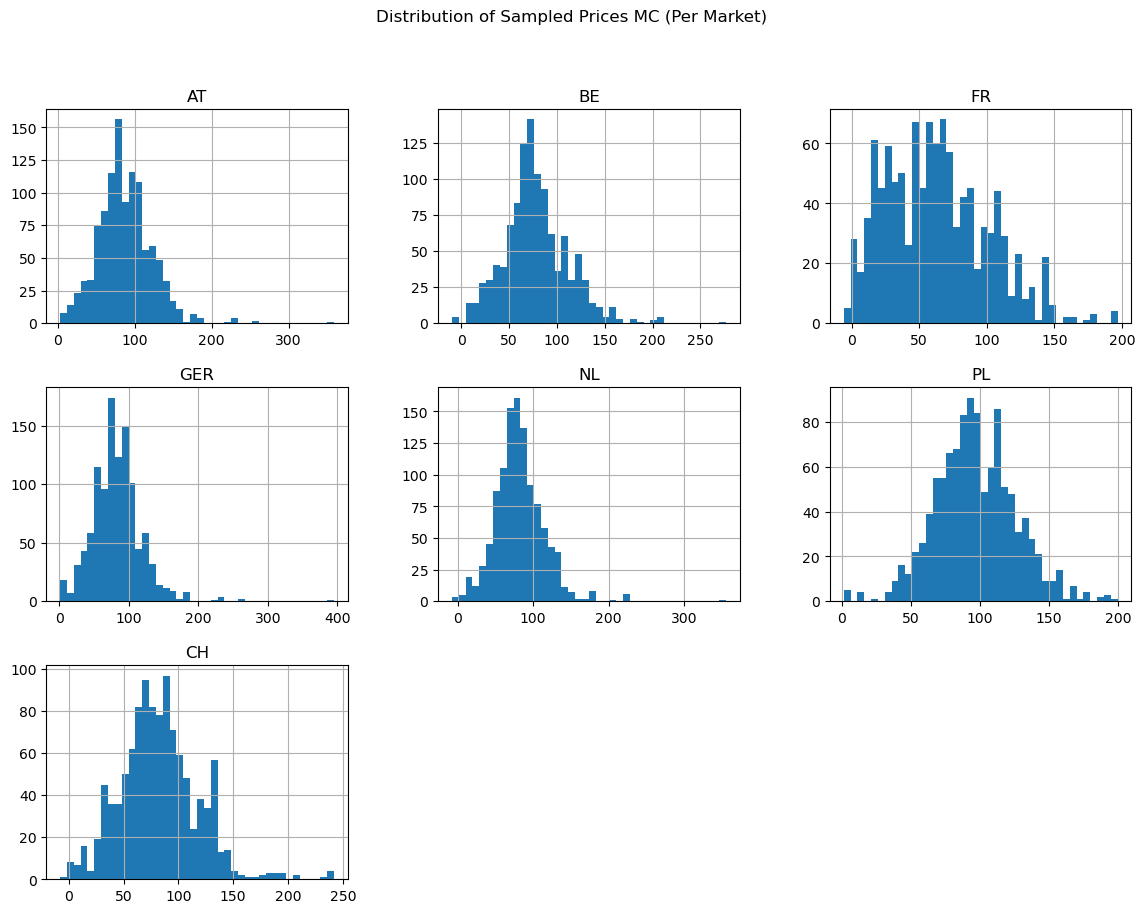

C:\Users\gulis\anaconda3\Lib\site-packages\scipy\stats\_continuous_distns.py:6912: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


   Market Distribution   KS Stat       p-value
0      AT        gamma  0.036383  1.055008e-01
1      AT            t  0.075274  7.077289e-06
2      BE        gamma  0.051904  5.085408e-03
3      BE            t  0.072374  1.825970e-05
12     CH        gamma  0.036735  9.965993e-02
13     CH            t  0.054699  2.630263e-03
4      FR        gamma  0.045243  2.128781e-02
5      FR            t  0.050170  7.522692e-03
7     GER            t  0.025005  4.883183e-01
6     GER        gamma  0.045857  1.881101e-02
8      NL        gamma  0.045751  1.921728e-02
9      NL            t  0.081811  7.287707e-07
11     PL            t  0.036066  1.110040e-01
10     PL        gamma  0.037070  9.435089e-02


,Expected Cost (MC),Expected Cost,"Risk (Std, MC)",Risk (Std)
P1 Non-Short,"915,018","919,894","281,445","281,904"
P2 UB-LB,"827,176","822,732","295,288","296,823"
P3 With Short,"960,803","957,938","249,052","246,852"


In [12]:
print("train 2 moment portfolio")
out = presults(train_df,test_df)

# Dağılımlar

In [13]:
def dist(data):
    results = []

    for col in data.columns:
        col_data = data[col].dropna()

        dists = {
            "normal": st.norm,
            "lognormal": st.lognorm,
            "gamma": st.gamma,
            "t": st.t
        }

        for name, dist_obj in dists.items():
            try:
                params = dist_obj.fit(col_data)
                ks_stat, p_value = st.kstest(col_data, name, args=params)

                results.append({
                    "Market": col,
                    "Distribution": name,
                    "KS Stat": ks_stat,
                    "p-value": p_value
                })

            except Exception:
                pass

    df_fit = pd.DataFrame(results)
    df_fit = df_fit.sort_values(["Market", "KS Stat"])

    ########################## PLOT ########################################
   
    p_df = pd.DataFrame(data, columns=train_df.columns)
    p_df.hist(figsize=(14,10), bins=40)
    plt.suptitle("Distribution of Sampled Prices Data (Per Market)")
    plt.show()
    
    return df_fit

C:\Users\gulis\anaconda3\Lib\site-packages\scipy\stats\_continuous_distns.py:6912: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


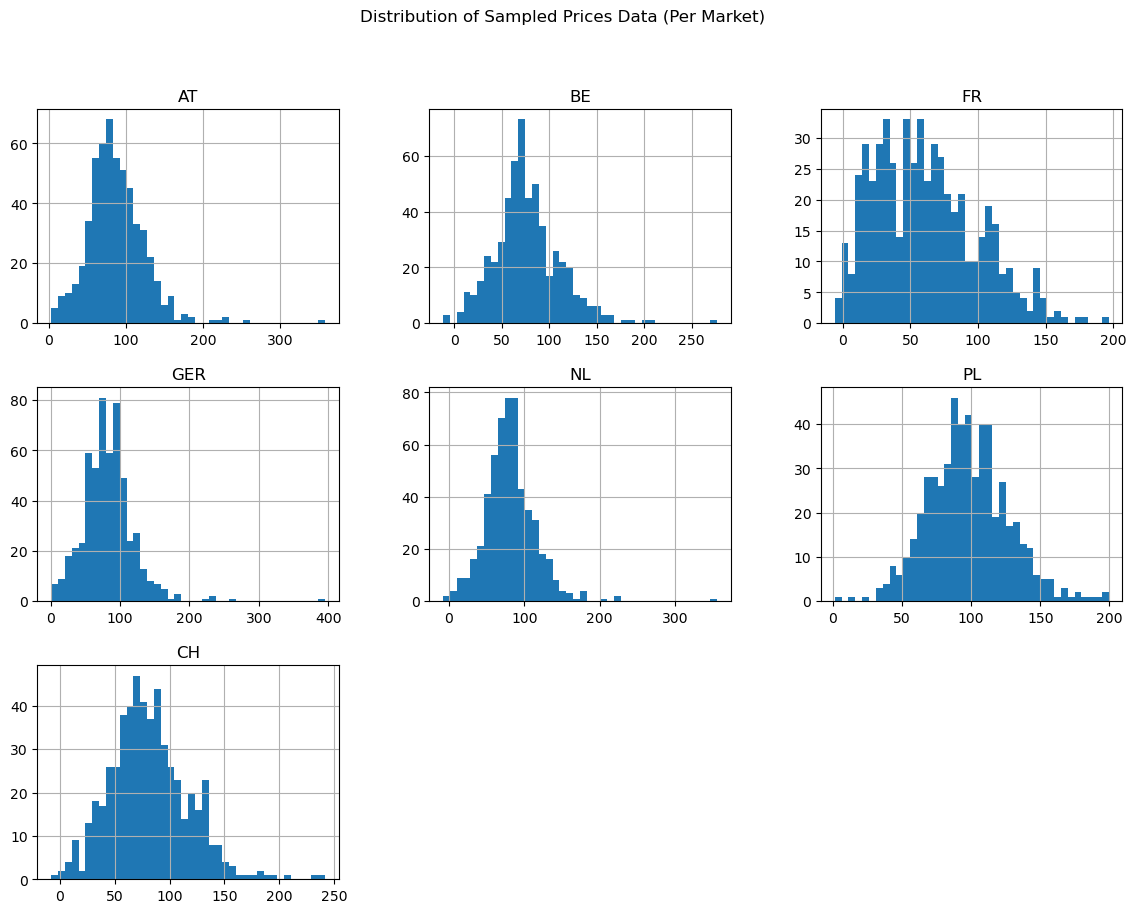

,Market,Distribution,KS Stat,p-value
0,AT,gamma,0.039610,0.343945
1,AT,t,0.069713,0.008982
3,BE,t,0.041874,0.280887
2,BE,gamma,0.048401,0.146402
12,CH,gamma,0.023970,0.901862
13,CH,t,0.053335,0.083912
4,FR,gamma,0.036956,0.428880
5,FR,t,0.063871,0.021335
7,GER,t,0.077404,0.002561
6,GER,gamma,0.984785,0.000000


In [14]:
display(dist(train_df))

# Efficient Frontier 

In [15]:
def plot_efficient_frontiers(
    prices,
    C=10000,
    gamma_grid=None,
    gamma_point=1.0,
    figsize=(10, 6)
):
    """
    3 portföy tasarımı için efficient frontier çizer.

    Portföyler:
    P1: Non-short        -> 0 <= w <= 1
    P2: Limited short    -> -0.3 <= w <= 0.3
    P3: With short       -> -3 <= w <= 3

    Gereken dış fonksiyonlar:
    - optimalPortfoliononshort(...)
    - optimalPortfolio(...)

    Returns
    -------
    result : dict
        {
            "frontier_p1": DataFrame,
            "frontier_p2": DataFrame,
            "frontier_p3": DataFrame,
            "points": DataFrame
        }
    """

    if gamma_grid is None:
        gamma_grid = np.logspace(-5, 1, 30)

    n = prices.shape[1]

    # Bounds
    ub_p2 = np.full(n, 0.3)
    lb_p2 = np.full(n, -0.3)

    ub_p3 = np.full(n, 3.0)
    lb_p3 = np.full(n, -3.0)

    def build_frontier_nonshort(prices, C, gamma_grid, lower_bounds=0.0, upper_bounds=1.0):
        rows = []

        for g in gamma_grid:
            try:
                w, E, V = optimalPortfoliononshort(
                    prices,
                    C=C,
                    gamma=float(g),
                    lower_bounds=lower_bounds,
                    upper_bounds=upper_bounds
                )
                rows.append([float(g), float(np.sqrt(V)), float(E)])
            except Exception:
                pass

        df_front = pd.DataFrame(rows, columns=["gamma", "risk", "cost"])
        df_front = df_front.replace([np.inf, -np.inf], np.nan).dropna()
        df_front = df_front.sort_values("risk").drop_duplicates(subset="risk")

        return df_front

    def get_current_portfolios(prices, C, gamma_point):
        w1, E1, V1 = optimalPortfoliononshort(
            prices, C=C, gamma=gamma_point
        )

        w2, E2, V2 = optimalPortfoliononshort(
            prices, C=C, gamma=gamma_point,
            lower_bounds=lb_p2, upper_bounds=ub_p2
        )

        w3, E3, V3 = optimalPortfoliononshort(
            prices, C=C, gamma=gamma_point,
            lower_bounds=lb_p3, upper_bounds=ub_p3
        )

        pts = pd.DataFrame({
            "Portfolio": [
                "P1 Non-Short",
                "P2 Limited LB-UB",
                "P3 With Short"
            ],
            "risk": [
                float(np.sqrt(V1)),
                float(np.sqrt(V2)),
                float(np.sqrt(V3))
            ],
            "cost": [
                float(E1),
                float(E2),
                float(E3)
            ]
        })

        weights = {
            "P1 Non-Short": w1,
            "P2 Limited LB-UB": w2,
            "P3 With Short": w3
        }

        return pts, weights

    # Build frontiers
    front1 = build_frontier_nonshort(
        prices, C, gamma_grid, lower_bounds=0.0, upper_bounds=1.0
    )

    front2 = build_frontier_nonshort(
        prices, C, gamma_grid, lower_bounds=lb_p2, upper_bounds=ub_p2
    )

    front3 = build_frontier_nonshort(
        prices, C, gamma_grid, lower_bounds=lb_p3, upper_bounds=ub_p3
    )

    pts, weights = get_current_portfolios(prices, C, gamma_point)

    # Info
    print("P1 valid points:", len(front1))
    print("P2 valid points:", len(front2))
    print("P3 valid points:", len(front3))

    # Plot
    plt.figure(figsize=figsize)

    if len(front1) > 1:
        plt.plot(front1["risk"], front1["cost"], linewidth=2, label="P1 Frontier - Non-Short")

    if len(front2) > 1:
        plt.plot(front2["risk"], front2["cost"], linewidth=2, label="P2 Frontier - Limited LB-UB")

    if len(front3) > 1:
        plt.plot(front3["risk"], front3["cost"], linewidth=2, label="P3 Frontier - With Short")

    for _, row in pts.iterrows():
        plt.scatter(row["risk"], row["cost"], s=80)
        plt.annotate(
            row["Portfolio"],
            (row["risk"], row["cost"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9
        )

    plt.xlabel("Risk (Standard Deviation)")
    plt.ylabel("Expected Cost")
    plt.title("Efficient Frontier of Portfolio Designs for USA Energy Market")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "frontier_p1": front1,
        "frontier_p2": front2,
        "frontier_p3": front3,
        "points": pts,
        "weights": weights
    }

test data
P1 valid points: 30
P2 valid points: 10
P3 valid points: 30


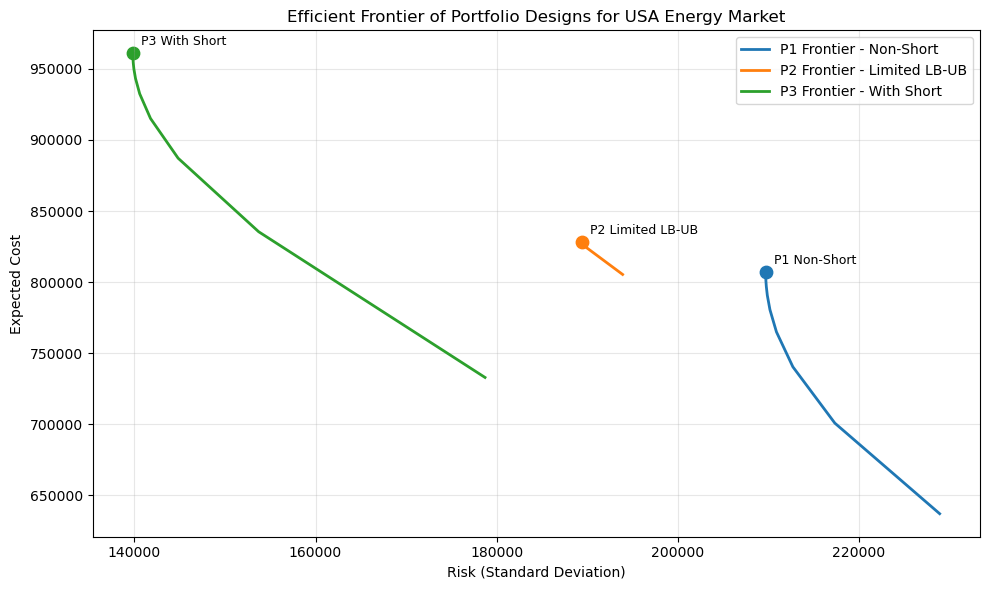

In [16]:
prices = test_df
C = 10000
print("test data")
result = plot_efficient_frontiers(
    prices=prices,
    C=C,
    gamma_grid=np.logspace(-5, 1, 30),
    gamma_point=1.0)

train data
P1 valid points: 30
P2 valid points: 30
P3 valid points: 30


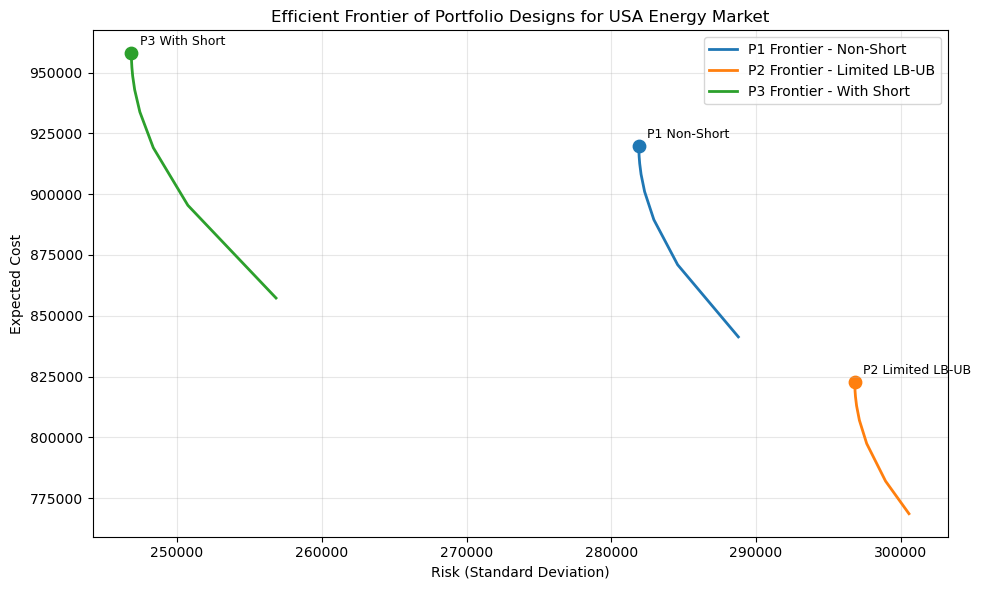

In [17]:
prices = train_df
C = 10000
print("train data")
result = plot_efficient_frontiers(
    prices=prices,
    C=C,
    gamma_grid=np.logspace(-5, 1, 30),
    gamma_point=1.0)

# HEDGE 

In [18]:
dfhe = pd.read_excel(r"C:\Users\gulis\Desktop\Portfolio Design for Electricty Market\Avrupa Market\nordpool_and_epex 2.xlsx",sheet_name="F")
dfhe = dfhe.tail(border)  # Test set (son 180 satır)

In [19]:
dfhe1 = pd.read_excel(r"C:\Users\gulis\Desktop\Portfolio Design for Electricty Market\Avrupa Market\F2.xlsx")
dfhe1 = dfhe1.tail(border)  # Test set (son 180 satır)

In [20]:
F1 = dfhe["F GER"]
F2 = dfhe1["TTF"]
F3 = dfhe1["BRENT"]
F4 = dfhe1["API2"]

w1 = out["w1"]
w2 = out["w2"]
w3 = out["w3"]

S_dict = {
    "P1 non-short": (test_df * w1.squeeze()).sum(axis=1),
    "P2 with limited UB-LB": (test_df * w2.squeeze()).sum(axis=1),
    "P3 with short": (test_df * w3.squeeze()).sum(axis=1)}
dfg =pd.DataFrame.from_dict(S_dict)

In [21]:
def run_mvh_block(S_dict, F, C=10000):

    rows = []

    for name, S in S_dict.items():
        S = S.reset_index(drop=True)
        F = F.reset_index(drop=True)

        df_h = pd.concat([S.rename("S"), F.rename("F")], axis=1).dropna()

        d = df_h.diff().dropna()
        h = d["S"].cov(d["F"]) / d["F"].var()

        X_unhedged = C * df_h["S"]
        X_hedged   = C * df_h["S"] - (h * C) * (df_h["F"] - df_h["F"].iloc[0])

        E_un  = X_unhedged.mean()
        Std_un = X_unhedged.std(ddof=0)
        E_h   = X_hedged.mean()
        Std_h  = X_hedged.std(ddof=0)

        rr = 100 * (1 - Std_h / Std_un)

        rows.append([name, float(h), E_un, E_h, Std_un, Std_h, rr])

    hedge_results = pd.DataFrame(rows, columns=[
        "Portfolio", "h*", "E (Unhedged)", "E (Hedged)",
        "Std (Unhedged)", "Std (Hedged)", "Risk Reduction %"
    ]).set_index("Portfolio")

    return hedge_results.style \
        .format("{:,.0f}", subset=["E (Unhedged)","Std (Unhedged)","E (Hedged)","Std (Hedged)"]) \
        .format("{:.2f}", subset=["h*"]) \
        .format("{:.2f}", subset=["Risk Reduction %"])

In [22]:
results = run_mvh_block(S_dict, F1, C=10000)
print("F GER")
display(results)

F GER


,h*,E (Unhedged),E (Hedged),Std (Unhedged),Std (Hedged),Risk Reduction %
Portfolio,,,,,,
P1 non-short,0.70,"990,794","994,619","243,271","193,534",20.45
P2 with limited UB-LB,0.73,"844,034","848,026","230,711","171,794",25.54
P3 with short,0.69,"988,957","992,730","208,959","165,123",20.98
